In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# some constants
omegb = 0.02226 # omega_b * h**2

######################3
#
# Lambda CDM

# E(z) squared
def Esq(z, Om):
    return Om*(1+z)**3 + 1 - Om

# inverse E(z)
def Einv(z, Efunc, Om):
    return 1/np.sqrt(Efunc(z, Om))

# integral of 1/E(z) with solve_ivp
def intdif(z, Efunc, Om):
    Ei = lambda x, y: Einv(x, Efunc, Om)
    z_unique, inverse = np.unique(z, return_inverse = True)
    sol = solve_ivp(Ei, [0, z_unique[-1]],[0], t_eval=z_unique)
    return sol.y.flatten()[inverse]

Text(0, 0.5, 'magnitudes aparentes')

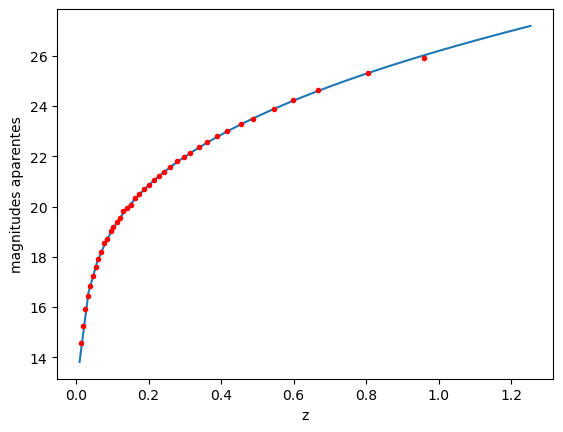

In [15]:
# read supernovae data
z, mb, dmb = np.loadtxt('../data/binned.txt', usecols=(2,4,5), unpack=True, skiprows=1)
z, idsort = np.unique(z, return_index=True) 
mb = mb[idsort]
dmb = dmb[idsort]

#M = -19.36; h = 0.7; Om = 0.3
M = -19.36; h = 0.7; Om = 0.3
#c/H0 = 3000/0.7
M_curl = M + 25  + 5 *np.log10 (3000/h)    # M_curl = 23.80  

zv = np.linspace(0.01,2.5,100)
d_sn = (1+zv)*intdif(zv, Esq, Om)
m_th = M_curl + 5*np.log10(d_sn)


plt.plot(np.log(1+zv),m_th)
plt.errorbar(np.log(1+z), mb, fmt='.', yerr=dmb, color='r')
plt.xlabel('z')
plt.ylabel('magnitudes aparentes')

Text(0, 0.5, 'magnitudes aparentes')

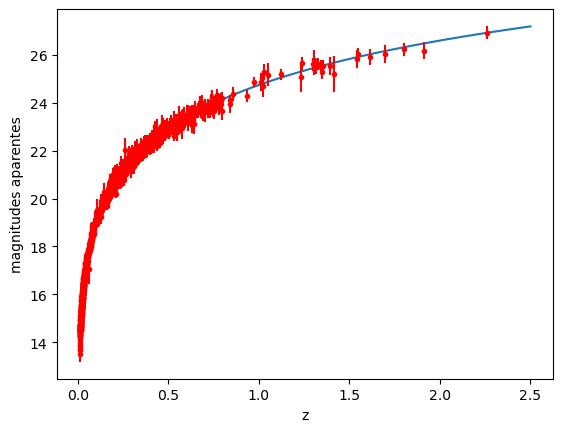

In [16]:
# ler dados de pantheon+
data = np.genfromtxt('../data/Pantheon+SH0ES.dat',names=True, dtype=None, encoding=None)
# Hubble flow only: drop calibrators and very low-z
mask = (data['IS_CALIBRATOR'] == 0) & (data['zHD'] > 0.01)
z_p   = data['zHD'][mask]
mb_p  = data['m_b_corr'][mask]
dmb_p = data['m_b_corr_err_DIAG'][mask]

plt.plot(zv,m_th)
plt.errorbar(z_p, mb_p, fmt='.', yerr=dmb_p, color='r')
plt.xlabel('z')
plt.ylabel('magnitudes aparentes')

In [17]:
import emcee
#import corner
#conda install -c conda-forge getdist
from getdist import MCSamples, plots
#pip install tqdm
from tqdm.notebook import tqdm

In [18]:
def log_likelihood_SnIa(theta, z, mb, dmb):
    Om, h = theta
    d_sn = (1+z)*intdif(z, Esq, Om)
    mu = 5*np.log10(d_sn)
    A = np.sum((mu-mb)**2/dmb**2)
    B = np.sum((mu-mb)/dmb**2)    
    C = np.sum(1/dmb**2)
    return -0.5 * (A-B**2/C)

def log_prior(theta):
    Om, h = theta
    if 0.2 < Om < 0.5 and 0.5 < h < 0.9:
        return 0.0
    return -np.inf

def log_probability(theta, z, mb, dmb):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_SnIa(theta, z, mb, dmb)    

100%|██████████████████████████████████████| 5000/5000 [01:46<00:00, 46.93it/s]


(10432, 2)


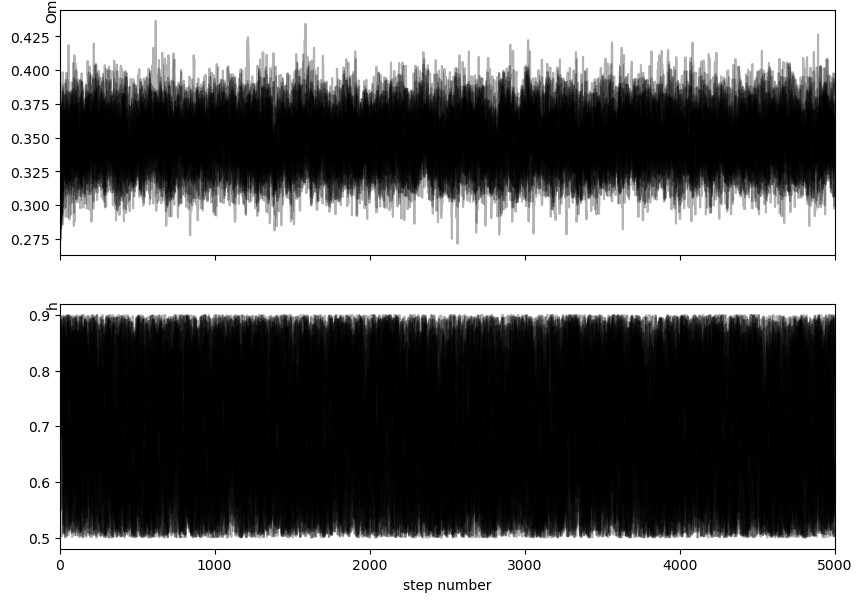

In [19]:
#pontos iniciais para parameteros Om, h
fonte = np.array([0.3,0.8])

#pos = soln.x + 1e-4 * np.random.randn(32, 3)
pos = fonte + 1e-2*np.random.randn(32, 2)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z_p, mb_p, dmb_p))
sampler.run_mcmc(pos, 5000, progress=True);

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["Om", "h"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(0, 1)

axes[-1].set_xlabel("step number");

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

filename = 'ola_sn'
np.save(filename, samples)

Removed no burn in


Om = 0.348\pm 0.019
h = 0.70\pm 0.12


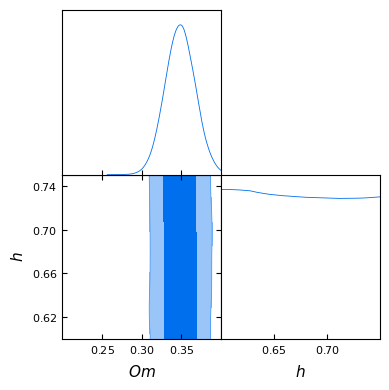

In [20]:
# use getdist  -------------------------------------------------
#
#conda install -c conda-forge getdist
samples_g = MCSamples(samples=samples, names=labels, labels=labels, settings=dict(smooth_scale_2D=1))

g = plots.get_subplot_plotter()
g.triangle_plot([samples_g], filled=True, param_limits={'h':(0.6,0.75),'Om':(0.2,0.4)})

print(samples_g.getInlineLatex('Om', limit=1))
print(samples_g.getInlineLatex('h', limit=1))

#g2 = plots.get_single_plotter()
#g2.plot_1d(samples_g,'h')

#g4 = plots.get_single_plotter()
#g4.plot_1d(samples_g,'Om',lims=[0.2,0.4])


#g3 = plots.get_single_plotter()
#g3.plot_2d(samples_g,param_pair=['Om','h'],filled=False, lims=[0.2, 0.4, 0.6,0.75])

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def Ez(z,*param):
    if modelo == 1:
        Om = param[0]
        return np.sqrt(Om*(1+z)**3 + 1 - Om)
    elif modelo == 2:
        Om, lamb = param
        return np.sqrt(3/(3-lamb**2)*Om*(1+z)**3 + (1 - 3/(3-lamb**2)*Om)**(1+z)**(lamb**2))  

def Dc(z, *param):
        Ei = lambda x, y: 1/Ez(x, *param)
        z_unique, inverse = np.unique(z, return_inverse = True)   
        sol = solve_ivp(Ei, [0, z_unique[-1]],[0], t_eval=z_unique)
        #sol = solve_ivp(Ei, [0, z[-1]],[0.0], t_eval=z)
        #return sol.y.flatten()
        return np.asarray(sol.y).flatten()[inverse]        

Text(0, 0.5, 'magnitudes aparentes')

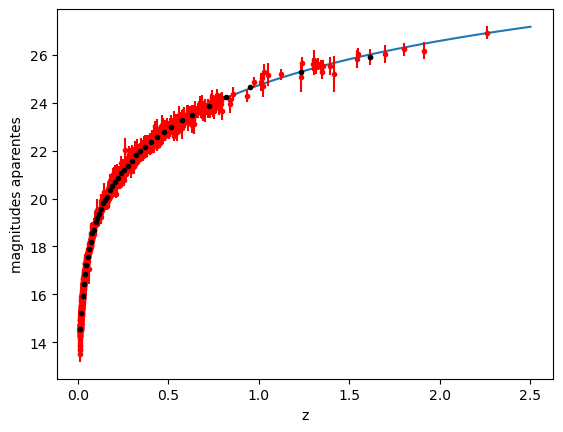

In [15]:
#modelo = 1; Om = 0.3; h = 0.7; lamb = []
modelo = 2; Om = 0.3; h = 0.7; lamb = 0.3

#M = -19.36; h = 0.7; Om = 0.3
M = -19.36; h = 0.7; Om = 0.3
#c/H0 = 3000/0.7
M_curl = M + 25  + 5 *np.log10 (3000/h)    # M_curl = 23.80  
zv = np.linspace(0.01,2.5,100)
d_sn = (1+zv)*Dc(zv,Om,lamb)
m_th = M_curl + 5*np.log10(d_sn)

# ler binned data
z, mb, dmb = np.loadtxt('../data/binned.txt', usecols=(2,4,5), unpack=True, skiprows=1)
z, idsort = np.unique(z, return_index=True) 
mb = mb[idsort]
dmb = dmb[idsort]

# ler dados de pantheon+
data = np.genfromtxt('../data/Pantheon+SH0ES.dat',names=True, dtype=None, encoding=None)
# Hubble flow only: drop calibrators and very low-z
mask = (data['IS_CALIBRATOR'] == 0) & (data['zHD'] > 0.01)
z_p   = data['zHD'][mask]
mb_p  = data['m_b_corr'][mask]
dmb_p = data['m_b_corr_err_DIAG'][mask]




plt.plot(zv,m_th)
plt.errorbar(z_p, mb_p, fmt='.', yerr=dmb_p, color='r')
plt.errorbar(z, mb, fmt='.', yerr=dmb, color='k')
plt.xlabel('z')
plt.ylabel('magnitudes aparentes')


In [11]:
def log_likelihood_SnIa(theta, z, mb, dmb):
    Om, h, lamb = theta
    d_sn = (1+z)*Dc(z,Om,lamb)
    mu = 5*np.log10(d_sn)
    A = np.sum((mu-mb)**2/dmb**2)
    B = np.sum((mu-mb)/dmb**2)    
    C = np.sum(1/dmb**2)
    return -0.5 * (A-B**2/C)

def log_prior(theta):
    Om, h, lamb = theta
    if 0.2 < Om < 0.5 and 0.5 < h < 0.9 and -0.3 < lamb < 0.3:        
        return 0.0
    return -np.inf

def log_probability(theta, z, mb, dmb):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    lp = lp + log_likelihood_SnIa(theta, z, mb, dmb)
    return lp      

  0%|                                                 | 0/5000 [00:00<?, ?it/s]/Users/nelson/opt/anaconda3/envs/cosmology/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 5000/5000 [01:39<00:00, 50.09it/s]


(10432, 3)


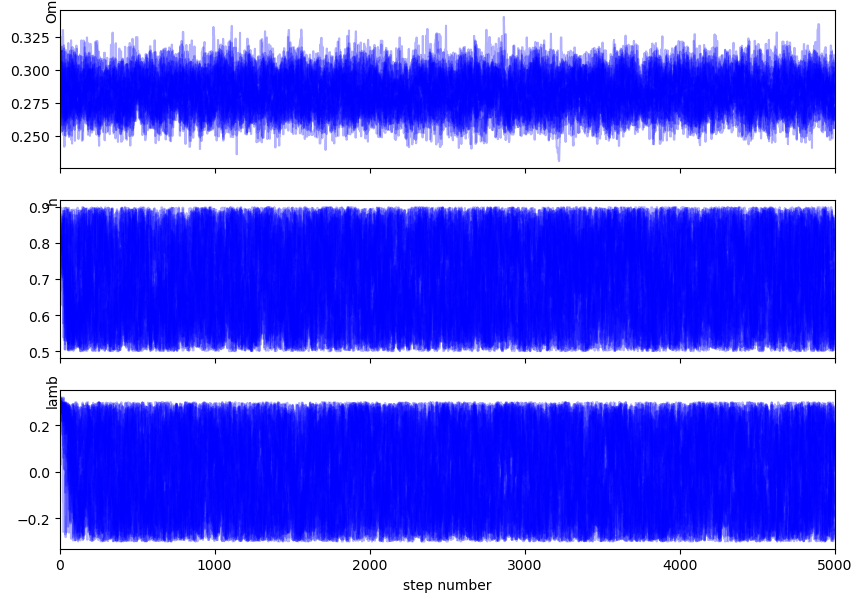

In [16]:
import emcee
#import corner
#conda install -c conda-forge getdist
from getdist import MCSamples, plots
#pip install tqdm
from tqdm.notebook import tqdm

#pontos iniciais para parameteros Om, h
fonte = np.array([0.3,0.8,0.3])

pos = fonte + 1e-2 * np.random.randn(32, 3)
#pos = fonte + 1e-2*np.random.randn(32, 2)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z, mb, dmb))
sampler.run_mcmc(pos, 5000, progress=True);

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["Om", "h", "lamb"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "b", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(0, 1)

axes[-1].set_xlabel("step number");

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

filename = 'ola_sn'
np.save(filename, samples)

Removed no burn in


Om = 0.283^{+0.012}_{-0.013}
h = 0.70\pm 0.12
lamb = 0.00\pm 0.18


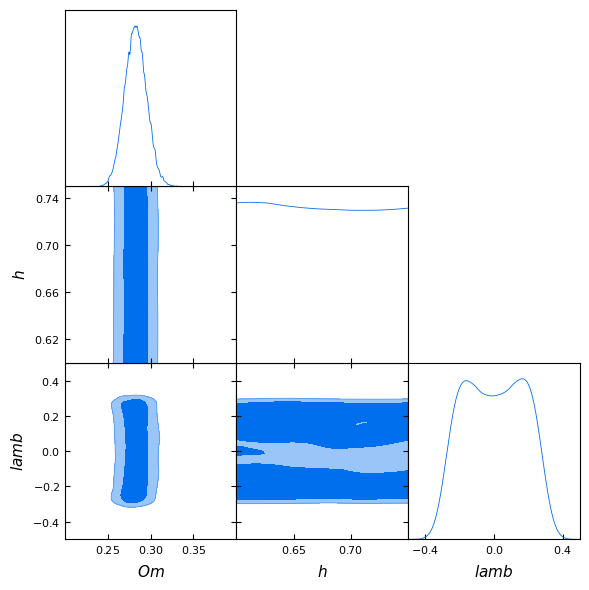

In [17]:
# use getdist  -------------------------------------------------
#
#conda install -c conda-forge getdist
samples_g = MCSamples(samples=samples, names=labels, labels=labels, settings=dict(smooth_scale_2D=1))

g = plots.get_subplot_plotter()
g.triangle_plot([samples_g], filled=True, param_limits={'lamb':(-0.5,0.5),'h':(0.6,0.75),'Om':(0.2,0.4)})

print(samples_g.getInlineLatex('Om', limit=1))
print(samples_g.getInlineLatex('h', limit=1))
print(samples_g.getInlineLatex('lamb', limit=1))